# Hallucination Snowballing in Sequential LLM Agents — Bidirectional-Entailment Consistency Filtering
**NLP project · re-implementation of the NLP-heavy core of** *Xu & Wu, "Mitigating LLM Hallucination Snowballing in Multiagent Systems via Context-Aware Semantic Consistency Reasoning", IEEE TNNLS 37(8), 2026.*

**What this notebook does (runs on a free Colab T4):**

| Paper component | Implemented here |
|---|---|
| Sequential multi-agent chain (Agent k output → Agent k+1 input) | 3-agent chain on HotpotQA: *Evidence Extractor → Reasoner → Answerer* (downstream agents see **only** upstream text, so errors really propagate) |
| N candidate responses per agent | Temperature sampling, N up to 10 |
| Contextual embeddings + NLI entailment | `microsoft/deberta-large-mnli` (question-conditioned: premise = *question + answer*) |
| Bidirectional entailment `A⇒B ∧ B⇒A > θ` (Eq. 28–29) | `cluster_responses(mode="bidirectional")` using the representative/transitivity trick of Algorithm 1 (O(N·K) NLI calls, not O(N²)) |
| Largest cluster `C*`, ratio `ρ=|C*|/N ≥ Acc` else conservative answer (Alg. 1) | `select_response` (abstain = `UNRESOLVED`, which is propagated) |
| BERTScore with threshold τ to flag hallucination (Eq. 8–12) | `bert-score`; τ is auto-set from the baseline distribution |
| Baseline vs. proposed, effect of **N** and **θ** | Main comparison + N / θ / ρ sweeps |

**Extra research content beyond the paper (so the project is more than a re-run):**
1. *Ideal-input (oracle)* run → measures the snowball gap, as in the paper's Table I.
2. **Snowball evidence**: P(final answer wrong | Agent-1 hallucinated) vs. P(wrong | Agent-1 fine).
3. **Ablation of the consistency test**: exact-string majority vs. embedding-cosine clustering vs. one-way entailment vs. **bidirectional** entailment.
4. Risk–coverage trade-off (hallucination forwarded vs. abstention rate) via the ρ sweep.
5. Paired bootstrap confidence interval for the accuracy improvement.
6. Qualitative case studies with the actual clusters.

> Set the runtime to **GPU (T4)**: *Runtime → Change runtime type*. Default settings (100 questions, N=10) take roughly 25–40 min in total; lower `N_EVAL` for a quick smoke test.

In [17]:
!pip -q install datasets bert-score sentence-transformers accelerate
import torch; print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE - switch runtime to GPU!")

GPU: Tesla T4


## 1. Configuration

In [18]:
# ---------------- models ----------------
LLM_NAME  = "Qwen/Qwen2.5-1.5B-Instruct"        # swap for Qwen2.5-3B-Instruct for a stronger (slower) agent
NLI_NAME  = "microsoft/deberta-large-mnli"       # entailment model (same family used by semantic-entropy work)
EMB_NAME  = "sentence-transformers/all-MiniLM-L6-v2"  # sentence embeddings (baseline clustering + medoid choice)
BERT_MODEL = "distilroberta-base"                # BERTScore backbone (fast; use roberta-large for the final report)

# ---------------- data / experiment ----------------
N_EVAL        = 100     # number of HotpotQA questions for the main experiment
N_DISTRACTORS = 2       # distractor paragraphs added to the 2 gold paragraphs
SEED          = 42

# ---------------- method hyper-parameters ----------------
N_SAMPLES   = 10        # N: candidate responses per agent (paper picks N=10)
TEMPERATURE = 0.8
TOP_P       = 0.95
THETA       = 0.90      # entailment-probability threshold (paper picks 0.92)
RHO         = 0.50      # min |C*|/N to trust a cluster (paper's 'Acc'); below -> conservative answer
MAX_NEW     = (96, 64, 24)   # max new tokens for agent 1, 2, 3
BATCH       = 8         # prompts per generate() call (x N sampled sequences each)

# ---------------- sweeps / ablations ----------------
N_LIST      = [1, 3, 5, 7, 10]
THETA_LIST  = [0.5, 0.7, 0.8, 0.9, 0.95, 0.98]
RHO_LIST    = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
EMB_THETA   = 0.80      # cosine threshold for the embedding-clustering ablation
RUN_E2E_ABLATION = True # end-to-end ablation on the first N_ABL questions (extra ~10-15 min)
N_ABL       = 50

UNRESOLVED = "UNRESOLVED"

In [19]:
import os, re, json, time, random, string, collections, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch
warnings.filterwarnings("ignore")
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
assert torch.cuda.is_available(), "Please enable a GPU runtime"
DEV = "cuda"

## 2. Data — HotpotQA (distractor setting)
Gold evidence = the human-annotated *supporting facts*. It serves as (a) the reference for BERTScore of Agent 1 and (b) the *ideal input* for the oracle run.

In [20]:
from datasets import load_dataset
try:
    ds = load_dataset("hotpotqa/hotpot_qa", "distractor", split="validation")
except Exception as e:
    print("Primary load failed -> trying parquet branch:", repr(e)[:150])
    ds = load_dataset("hotpotqa/hotpot_qa", "distractor", split="validation", revision="refs/convert/parquet")

def build_examples(ds, n, seed):
    rng = random.Random(seed)
    order = list(range(len(ds))); rng.shuffle(order)
    out = []
    for i in order:
        ex = ds[i]
        titles, sents = ex["context"]["title"], ex["context"]["sentences"]
        sf = ex["supporting_facts"]
        gold_titles = list(dict.fromkeys(sf["title"]))
        if len(gold_titles) < 2 or any(t not in titles for t in gold_titles): continue
        evid = []
        for t, s in zip(sf["title"], sf["sent_id"]):
            k = titles.index(t)
            if s < len(sents[k]): evid.append(sents[k][s].strip())
        if not evid: continue
        distract = [t for t in titles if t not in gold_titles]; rng.shuffle(distract)
        keep = gold_titles + distract[:N_DISTRACTORS]; rng.shuffle(keep)
        ctx = "\n".join(f"[{t}] " + " ".join(x.strip() for x in sents[titles.index(t)]) for t in keep)
        out.append(dict(id=ex["id"], question=ex["question"], answer=ex["answer"], type=ex["type"],
                        context=ctx, gold_evidence=" ".join(evid)))
        if len(out) >= n: break
    return out

EX = build_examples(ds, N_EVAL, SEED)
print(len(EX), "questions |", collections.Counter(e["type"] for e in EX))
e = EX[0]; print("\nQ:", e["question"], "\nGold answer:", e["answer"], "\nGold evidence:", e["gold_evidence"])

100 questions | Counter({'bridge': 79, 'comparison': 21})

Q: What was Iqbal F. Qadir on when he participated in an attack on a radar station located on western shore of the Okhamandal Peninsula? 
Gold answer: flotilla 
Gold evidence: He is renown for his participation in second war with India when he was part of the flotilla that attacked the radar station in Dwarka, India. It is located on the western shore of the Okhamandal Peninsula on the right bank of the Gomti River.


## 3. Load models (LLM agent · NLI · sentence embedder · BERTScore)

In [5]:
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModelForSequenceClassification
from sentence_transformers import SentenceTransformer
from bert_score import BERTScorer

tok = AutoTokenizer.from_pretrained(LLM_NAME, padding_side="left")
if tok.pad_token is None: tok.pad_token = tok.eos_token
llm = AutoModelForCausalLM.from_pretrained(LLM_NAME, torch_dtype=torch.float16).to(DEV).eval()

nli_tok = AutoTokenizer.from_pretrained(NLI_NAME)
nli = AutoModelForSequenceClassification.from_pretrained(NLI_NAME).half().to(DEV).eval()
ENT_ID = [i for i, l in nli.config.id2label.items() if l.lower().startswith("entail")][0]
print("NLI labels:", nli.config.id2label, "-> entailment id", ENT_ID)

embedder = SentenceTransformer(EMB_NAME, device=DEV)
bscorer  = BERTScorer(model_type=BERT_MODEL, lang="en", device=DEV, batch_size=32)
print("models ready | GPU mem used: %.1f GB" % (torch.cuda.memory_allocated()/1e9))

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  331MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: distilroberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


models ready | GPU mem used: 4.3 GB


## 4. Core utilities: answer metrics · batched LLM sampling · cached NLI / embeddings / BERTScore

In [6]:
# ---------- answer normalisation & metrics (SQuAD/HotpotQA style) ----------
def norm_ans(s):
    s = s.lower()
    s = "".join(ch for ch in s if ch not in set(string.punctuation))
    s = re.sub(r"\b(a|an|the)\b", " ", s)
    return " ".join(s.split())

def f1_score(pred, gold):
    p, g = norm_ans(pred).split(), norm_ans(gold).split()
    common = collections.Counter(p) & collections.Counter(g); ns = sum(common.values())
    if ns == 0: return 0.0
    pr, rc = ns/len(p), ns/len(g); return 2*pr*rc/(pr+rc)

def exact_match(pred, gold): return float(norm_ans(pred) == norm_ans(gold))

def contains(pred, gold):
    # gold tokens appear as a contiguous span inside the prediction
    p, g = norm_ans(pred).split(), norm_ans(gold).split()
    if not g: return 0.0
    return float(any(p[i:i+len(g)] == g for i in range(len(p)-len(g)+1)))

def is_abstain(pred):
    n = norm_ans(pred)
    return n in ("", "unknown", "unresolved") or n.startswith("unknown")

# ---------- batched generation (greedy or N sampled sequences per prompt) ----------
@torch.no_grad()
def llm_generate(messages_list, max_new_tokens, n=1, sample=False):
    outs = []
    for b in range(0, len(messages_list), BATCH):
        chunk = messages_list[b:b+BATCH]
        prompts = [tok.apply_chat_template(m, tokenize=False, add_generation_prompt=True) for m in chunk]
        enc = tok(prompts, return_tensors="pt", padding=True).to(DEV)
        kw = dict(max_new_tokens=max_new_tokens, pad_token_id=tok.pad_token_id)
        if sample: kw.update(do_sample=True, temperature=TEMPERATURE, top_p=TOP_P, num_return_sequences=n)
        else:      kw.update(do_sample=False, temperature=None, top_p=None, top_k=None)
        gen = llm.generate(**enc, **kw)[:, enc["input_ids"].shape[1]:]
        texts = tok.batch_decode(gen, skip_special_tokens=True)
        k = n if sample else 1
        for j in range(len(chunk)):
            outs.append([t.strip().replace("\n", " ") for t in texts[j*k:(j+1)*k]])
    return outs

# ---------- NLI: P(entailment) with cache ----------
_nli_cache = {}
@torch.no_grad()
def entail_prob(pairs, bs=48):
    todo = [p for p in dict.fromkeys(pairs) if p not in _nli_cache]
    for b in range(0, len(todo), bs):
        chunk = todo[b:b+bs]
        enc = nli_tok([p for p, _ in chunk], [h for _, h in chunk], return_tensors="pt",
                      padding=True, truncation=True, max_length=512).to(DEV)
        pr = nli(**enc).logits.float().softmax(-1)[:, ENT_ID].cpu().tolist()
        for pair, v in zip(chunk, pr): _nli_cache[pair] = v
    return [_nli_cache[p] for p in pairs]

# ---------- sentence embeddings with cache ----------
_emb_cache = {}
def embed(texts):
    todo = [t for t in dict.fromkeys(texts) if t not in _emb_cache]
    if todo:
        E = embedder.encode(todo, convert_to_tensor=True, normalize_embeddings=True, batch_size=64)
        for t, e in zip(todo, E): _emb_cache[t] = e
    return torch.stack([_emb_cache[t] for t in texts])

# ---------- BERTScore F1 with cache ----------
_bs_cache = {}
def bert_f1(cands, refs):
    cands = [c if c.strip() else "." for c in cands]
    todo = [k for k in dict.fromkeys(zip(cands, refs)) if k not in _bs_cache]
    if todo:
        _, _, F = bscorer.score([c for c, _ in todo], [r for _, r in todo])
        for k, f in zip(todo, F.tolist()): _bs_cache[k] = f
    return [_bs_cache[k] for k in zip(cands, refs)]

## 5. The method — bidirectional-entailment clustering (paper Eq. 28–31, Algorithm 1)

For each agent we draw **N** candidates and cluster them with **context-aware** NLI (premise/hypothesis = *question + answer*):

* Two responses are *equivalent* iff `P(entail(a→b)) > θ` **and** `P(entail(b→a)) > θ`.
* Because equivalence is transitive, a new response is only compared with **one representative per existing cluster** → at most N·K comparisons instead of N².
* `C* = argmax |C|`, `ρ = |C*|/N`. If `ρ ≥ RHO` forward a representative of `C*` (we take the **medoid** in embedding space, not just the first member); otherwise forward the conservative answer `UNRESOLVED` so the next agent does not build on an unreliable claim.

`mode` lets us ablate the consistency test: `exact` (normalised string match), `embedding` (cosine), `unidirectional` (rep⇒candidate only), `bidirectional` (proposed).

In [7]:
def cluster_responses(question, answers, theta, mode="bidirectional"):
    # Greedy representative-based clustering. Returns list of clusters (lists of indices into `answers`).
    texts = [f"{question} {a}" for a in answers]
    reps, clusters = [], []
    for i, a in enumerate(answers):
        placed = False
        key = norm_ans(a)
        for c, r in enumerate(reps):                     # free shortcut: identical strings
            if norm_ans(answers[r]) == key:
                clusters[c].append(i); placed = True; break
        if not placed and reps and mode != "exact":
            if mode == "embedding":
                sims = (embed([answers[r] for r in reps]) @ embed([a]).T).squeeze(-1).tolist()
                scores = sims
            else:
                fw = entail_prob([(texts[r], texts[i]) for r in reps])      # rep  => cand
                if mode == "unidirectional": scores = fw
                else:
                    bw = entail_prob([(texts[i], texts[r]) for r in reps])  # cand => rep
                    scores = [min(f, b) for f, b in zip(fw, bw)]            # both directions must hold
            best = int(np.argmax(scores))
            if scores[best] > theta: clusters[best].append(i); placed = True
        if not placed: reps.append(i); clusters.append([i])
    return clusters

def medoid(answers, members):
    if len(members) <= 2: return members[0]
    E = embed([answers[m] for m in members]); c = E.mean(0)
    return members[int((E @ c).argmax())]

def select_response(question, answers, theta, rho, mode="bidirectional", on_fail="abstain"):
    answers = [a for a in answers if a.strip()]
    if not answers: return UNRESOLVED, dict(ratio=0.0, k=0, abstain=True, clusters=[])
    cl = cluster_responses(question, answers, theta, mode)
    cl_sorted = sorted(cl, key=len, reverse=True)
    cstar = cl_sorted[0]; ratio = len(cstar) / len(answers)
    info = dict(ratio=ratio, k=len(cl), abstain=False,
                clusters=[(len(c), answers[c[0]][:160]) for c in cl_sorted[:4]])
    if ratio >= rho or on_fail == "largest":
        return answers[medoid(answers, cstar)], info
    info["abstain"] = True
    return UNRESOLVED, info

## 6. The three agents (sequential chain)

In [8]:
def m_agent1(e):
    return [{"role": "system", "content": "You are an evidence-extraction agent. Read the passages and write the 1-3 sentences of facts needed to answer the question. Use only facts stated in the passages. Be concise."},
            {"role": "user", "content": f"Passages:\n{e['context']}\n\nQuestion: {e['question']}\n\nEvidence:"}]

def m_agent2(e, evidence):
    return [{"role": "system", "content": "You are a reasoning agent. Using ONLY the evidence provided, reason in at most two sentences and state the conclusion that answers the question."},
            {"role": "user", "content": f"Question: {e['question']}\nEvidence: {evidence}\n\nConclusion:"}]

def m_agent3(e, conclusion):
    return [{"role": "system", "content": "You are the answering agent. Given the question and the conclusion, output ONLY the final short answer (a few words, or yes/no). Do not explain."},
            {"role": "user", "content": f"Question: {e['question']}\nConclusion: {conclusion}\n\nFinal answer:"}]

BUILDERS = [lambda e, up: m_agent1(e), m_agent2, m_agent3]

# Stage-1 input never depends on the method -> sample once, reuse for every sweep/ablation
_S1_CACHE = {}
def stage1_samples(exs, n_max=None):
    n_max = n_max or max(N_SAMPLES, max(N_LIST))
    todo = [e for e in exs if e["id"] not in _S1_CACHE]
    if todo:
        torch.manual_seed(SEED)
        outs = llm_generate([m_agent1(e) for e in todo], MAX_NEW[0], n=n_max, sample=True)
        for e, o in zip(todo, outs): _S1_CACHE[e["id"]] = o
    return _S1_CACHE

def agent_stage(stage, exs, upstream, method, n, theta, rho, mode, on_fail, metas):
    out = [UNRESOLVED] * len(exs)
    live = [i for i, u in enumerate(upstream) if u != UNRESOLVED]      # UNRESOLVED propagates, no LLM call
    msgs = [BUILDERS[stage](exs[i], upstream[i]) for i in live]
    if method == "consistency":
        torch.manual_seed(SEED + stage)
        for i, s in zip(live, llm_generate(msgs, MAX_NEW[stage], n=n, sample=True)):
            out[i], metas[i][f"s{stage+1}"] = select_response(exs[i]["question"], s, theta, rho, mode, on_fail)
    else:
        for i, o in zip(live, llm_generate(msgs, MAX_NEW[stage])): out[i] = o[0]
    return out

def run_pipeline(exs, method, n=None, theta=None, rho=None, mode="bidirectional", on_fail="abstain"):
    # method: 'baseline' (greedy chain) | 'oracle' (gold evidence into agent 2) | 'consistency' (proposed)
    n = n or N_SAMPLES; theta = THETA if theta is None else theta; rho = RHO if rho is None else rho
    metas = [dict() for _ in exs]
    if method == "oracle":
        s1 = [e["gold_evidence"] for e in exs]
    elif method == "baseline":
        s1 = [o[0] for o in llm_generate([m_agent1(e) for e in exs], MAX_NEW[0])]
    else:
        samp = stage1_samples(exs); s1 = []
        for i, e in enumerate(exs):
            t, info = select_response(e["question"], samp[e["id"]][:n], theta, rho, mode, on_fail)
            s1.append(t); metas[i]["s1"] = info
    s2 = agent_stage(1, exs, s1, method, n, theta, rho, mode, on_fail, metas)
    s3 = agent_stage(2, exs, s2, method, n, theta, rho, mode, on_fail, metas)
    return [dict(id=e["id"], s1=a, s2=b, s3=c, meta=m) for e, a, b, c, m in zip(exs, s1, s2, s3, metas)]

## 7. Evaluation helpers
τ (the paper's BERTScore hallucination threshold) is set *relative to the data*: the 25th percentile of the baseline Agent-1 BERTScore distribution; an Agent-1 output below τ is flagged as hallucinated.

In [9]:
TAU = None
def evaluate(recs, exs, name):
    gold = [e["answer"] for e in exs]
    s3 = [r["s3"] for r in recs]; ab = np.array([is_abstain(x) for x in s3])
    acc = np.array([contains(p, g) for p, g in zip(s3, gold)])
    em  = np.mean([exact_match(p, g) for p, g in zip(s3, gold)])
    f1  = np.mean([f1_score(p, g) for p, g in zip(s3, gold)])
    s2a = np.mean([contains(r["s2"], g) for r, g in zip(recs, gold)])
    ans1 = [i for i, r in enumerate(recs) if r["s1"] != UNRESOLVED]
    bs1 = np.array(bert_f1([recs[i]["s1"] for i in ans1], [exs[i]["gold_evidence"] for i in ans1])) if ans1 else np.array([])
    hall_fwd = (np.sum(bs1 < TAU) / len(recs)) if TAU is not None and len(bs1) else np.nan
    return dict(Method=name, Acc=acc.mean(), EM=em, F1=f1, Abstain=ab.mean(),
                SelAcc=acc[~ab].mean() if (~ab).any() else np.nan, S2_Acc=s2a,
                S1_BERTScore=bs1.mean() if len(bs1) else np.nan, S1_HallucFwd=hall_fwd)

def paired_bootstrap(a, b, iters=5000, seed=0):
    # CI for mean(b - a) over per-question correctness
    a, b = np.array(a), np.array(b); rng = np.random.default_rng(seed)
    d = [ (b[i]-a[i]).mean() for i in (rng.integers(0, len(a), len(a)) for _ in range(iters)) ]
    return (b-a).mean(), np.percentile(d, 2.5), np.percentile(d, 97.5)

def correct_vec(recs, exs): return [contains(r["s3"], e["answer"]) for r, e in zip(recs, exs)]

## 8. Main experiment — baseline vs. ideal input vs. consistency-aware pipeline

In [10]:
t0 = time.time()
rec_base = run_pipeline(EX, "baseline");  print("baseline done  %.0fs" % (time.time()-t0))
rec_orc  = run_pipeline(EX, "oracle");    print("oracle done    %.0fs" % (time.time()-t0))

# data-driven tau from the baseline distribution of Agent-1 BERTScore
bs_base = bert_f1([r["s1"] for r in rec_base], [e["gold_evidence"] for e in EX])
TAU = float(np.percentile(bs_base, 25)); print("tau (25th pct of baseline Agent-1 BERTScore) = %.4f" % TAU)

rec_prop = run_pipeline(EX, "consistency", mode="bidirectional")
print("proposed done  %.0fs" % (time.time()-t0))

main = pd.DataFrame([evaluate(rec_base, EX, "Baseline (greedy chain)"),
                     evaluate(rec_orc,  EX, "Ideal input (oracle upper bound)"),
                     evaluate(rec_prop, EX, f"Proposed (bidir. entailment, N={N_SAMPLES}, θ={THETA}, ρ={RHO})")])
display(main.round(4))

d, lo, hi = paired_bootstrap(correct_vec(rec_base, EX), correct_vec(rec_prop, EX))
print(f"Accuracy gain (proposed - baseline): {d:+.3f}  95% CI [{lo:+.3f}, {hi:+.3f}]  (paired bootstrap)")

baseline done  101s
oracle done    145s
tau (25th pct of baseline Agent-1 BERTScore) = 0.8833
proposed done  807s


,Method,Acc,EM,F1,Abstain,SelAcc,S2_Acc,S1_BERTScore,S1_HallucFwd
0,Baseline (greedy chain),0.20,0.16,0.1953,0.00,0.2000,0.53,0.9037,0.25
1,Ideal input (oracle upper bound),0.27,0.23,0.2914,0.00,0.2700,0.77,1.0000,0.00
2,"Proposed (bidir. entailment, N=10, θ=0.9, ρ=0.5)",0.05,0.05,0.0550,0.74,0.1923,0.16,0.8964,0.11


Accuracy gain (proposed - baseline): -0.150  95% CI [-0.230, -0.080]  (paired bootstrap)


## 9. Evidence of the snowball effect (baseline run)
If hallucinations snowball, the final answer should be much more likely to be wrong when **Agent 1 already hallucinated**.

In [11]:
c_base = np.array(correct_vec(rec_base, EX)); h1 = np.array(bs_base) < TAU
snow = pd.DataFrame({
    "Agent-1 output": ["hallucinated (BERTScore<τ)", "faithful (BERTScore≥τ)"],
    "n": [h1.sum(), (~h1).sum()],
    "P(final answer wrong)": [1 - c_base[h1].mean() if h1.any() else np.nan, 1 - c_base[~h1].mean() if (~h1).any() else np.nan]})
display(snow.round(3))
stage_err = {"Agent 1 (hallucinated rate)": h1.mean(),
             "Agent 2 (conclusion misses gold answer)": 1-np.mean([contains(r['s2'], e['answer']) for r, e in zip(rec_base, EX)]),
             "Agent 3 (final answer wrong)": 1-c_base.mean()}
print(pd.Series(stage_err).round(3).to_string())

,Agent-1 output,n,P(final answer wrong)
0,hallucinated (BERTScore<τ),25,0.8
1,faithful (BERTScore≥τ),75,0.8


Agent 1 (hallucinated rate)                0.25
Agent 2 (conclusion misses gold answer)    0.47
Agent 3 (final answer wrong)               0.80


## 10. Offline stage-1 sweeps (N, θ, ρ, consistency test)
Agent-1 candidates do not depend on upstream context, so the N=10 samples are drawn **once** and every configuration re-clusters them — cheap and perfectly paired. Metrics: mean BERTScore of the forwarded evidence, **hallucination forwarded** (fraction of all questions whose forwarded evidence has BERTScore<τ) and the abstention rate.

In [12]:
def s1_offline(mode, n, theta, rho, on_fail="abstain"):
    samp = stage1_samples(EX); sel, ab = [], []
    for e in EX:
        t, info = select_response(e["question"], samp[e["id"]][:n], theta, rho, mode, on_fail)
        sel.append(t); ab.append(info["abstain"])
    idx = [i for i, a in enumerate(ab) if not a]
    bs = np.array(bert_f1([sel[i] for i in idx], [EX[i]["gold_evidence"] for i in idx])) if idx else np.array([])
    return dict(mode=mode, N=n, theta=theta, rho=rho, Abstain=np.mean(ab),
                BERTScore=bs.mean() if len(bs) else np.nan,
                HallucFwd=np.sum(bs < TAU)/len(EX), HallucGivenAnswered=(bs < TAU).mean() if len(bs) else np.nan)

# reference rows
greedy_bs = bert_f1([r["s1"] for r in rec_base], [e["gold_evidence"] for e in EX])
ref = dict(mode="greedy baseline", N=1, theta=np.nan, rho=np.nan, Abstain=0.0, BERTScore=np.mean(greedy_bs),
           HallucFwd=np.mean(np.array(greedy_bs) < TAU), HallucGivenAnswered=np.mean(np.array(greedy_bs) < TAU))

t0 = time.time()
df_n     = pd.DataFrame([s1_offline("bidirectional", n, THETA, RHO) for n in N_LIST])
df_theta = pd.DataFrame([s1_offline("bidirectional", N_SAMPLES, th, RHO) for th in THETA_LIST])
df_rho   = pd.DataFrame([s1_offline("bidirectional", N_SAMPLES, THETA, r) for r in RHO_LIST])
df_mode  = pd.DataFrame([ref,
    s1_offline("exact", N_SAMPLES, 0, RHO), s1_offline("embedding", N_SAMPLES, EMB_THETA, RHO),
    s1_offline("unidirectional", N_SAMPLES, THETA, RHO), s1_offline("bidirectional", N_SAMPLES, THETA, RHO)])
print("sweeps done %.0fs" % (time.time()-t0))
print("\n== Effect of N =="); display(df_n.round(3))
print("== Effect of θ =="); display(df_theta.round(3))
print("== Effect of ρ (risk-coverage trade-off) =="); display(df_rho.round(3))
print("== Consistency test ablation =="); display(df_mode.round(3))

sweeps done 27s

== Effect of N ==


,mode,N,theta,rho,Abstain,BERTScore,HallucFwd,HallucGivenAnswered
0,bidirectional,1,0.9,0.5,0.00,0.899,0.37,0.370
1,bidirectional,3,0.9,0.5,0.51,0.904,0.11,0.224
2,bidirectional,5,0.9,0.5,0.65,0.904,0.09,0.257
3,bidirectional,7,0.9,0.5,0.67,0.905,0.07,0.212
4,bidirectional,10,0.9,0.5,0.63,0.896,0.11,0.297


== Effect of θ ==


,mode,N,theta,rho,Abstain,BERTScore,HallucFwd,HallucGivenAnswered
0,bidirectional,10,0.50,0.5,0.53,0.903,0.11,0.234
1,bidirectional,10,0.70,0.5,0.57,0.902,0.11,0.256
2,bidirectional,10,0.80,0.5,0.60,0.902,0.11,0.275
3,bidirectional,10,0.90,0.5,0.63,0.896,0.11,0.297
4,bidirectional,10,0.95,0.5,0.66,0.896,0.10,0.294
5,bidirectional,10,0.98,0.5,0.68,0.896,0.09,0.281


== Effect of ρ (risk-coverage trade-off) ==


,mode,N,theta,rho,Abstain,BERTScore,HallucFwd,HallucGivenAnswered
0,bidirectional,10,0.9,0.2,0.06,0.897,0.29,0.309
1,bidirectional,10,0.9,0.3,0.25,0.899,0.21,0.280
2,bidirectional,10,0.9,0.4,0.46,0.901,0.14,0.259
3,bidirectional,10,0.9,0.5,0.63,0.896,0.11,0.297
4,bidirectional,10,0.9,0.6,0.74,0.904,0.06,0.231
5,bidirectional,10,0.9,0.7,0.79,0.902,0.06,0.286
6,bidirectional,10,0.9,0.8,0.87,0.889,0.06,0.462


== Consistency test ablation ==


,mode,N,theta,rho,Abstain,BERTScore,HallucFwd,HallucGivenAnswered
0,greedy baseline,1,NaN,NaN,0.00,0.904,0.25,0.250
1,exact,10,0.0,0.5,0.84,0.895,0.06,0.375
2,embedding,10,0.8,0.5,0.28,0.909,0.12,0.167
3,unidirectional,10,0.9,0.5,0.41,0.904,0.14,0.237
4,bidirectional,10,0.9,0.5,0.63,0.896,0.11,0.297


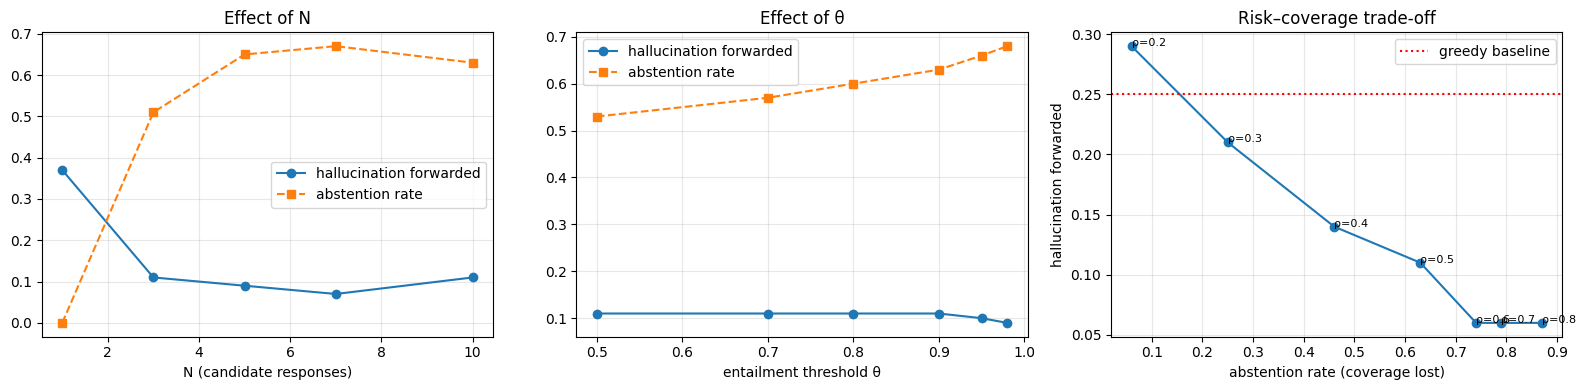

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].plot(df_n.N, df_n.HallucFwd, "o-", label="hallucination forwarded"); ax[0].plot(df_n.N, df_n.Abstain, "s--", label="abstention rate")
ax[0].set_xlabel("N (candidate responses)"); ax[0].set_title("Effect of N"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(df_theta.theta, df_theta.HallucFwd, "o-", label="hallucination forwarded"); ax[1].plot(df_theta.theta, df_theta.Abstain, "s--", label="abstention rate")
ax[1].set_xlabel("entailment threshold θ"); ax[1].set_title("Effect of θ"); ax[1].legend(); ax[1].grid(alpha=.3)
ax[2].plot(df_rho.Abstain, df_rho.HallucFwd, "o-"); [ax[2].annotate(f"ρ={r}", (a, h), fontsize=8) for r, a, h in zip(df_rho.rho, df_rho.Abstain, df_rho.HallucFwd)]
ax[2].axhline(ref["HallucFwd"], color="r", ls=":", label="greedy baseline"); ax[2].set_xlabel("abstention rate (coverage lost)"); ax[2].set_ylabel("hallucination forwarded")
ax[2].set_title("Risk–coverage trade-off"); ax[2].legend(); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.savefig("sweeps.png", dpi=160); plt.show()

## 11. End-to-end ablation of the consistency test (full 3-agent chain)
Re-runs the whole chain, so downstream agents genuinely receive the filtered upstream output.

In [14]:
abl_rows = []
if RUN_E2E_ABLATION:
    EXA = EX[:N_ABL]; t0 = time.time()
    cfgs = [("Baseline (greedy)", dict(method="baseline")),
            ("Exact-string majority",           dict(method="consistency", mode="exact")),
            (f"Embedding cosine (>{EMB_THETA})", dict(method="consistency", mode="embedding", theta=EMB_THETA)),
            ("One-way entailment",              dict(method="consistency", mode="unidirectional")),
            ("Bidirectional entailment (ours)", dict(method="consistency", mode="bidirectional")),
            ("Bidirectional, N=5",              dict(method="consistency", mode="bidirectional", n=5)),
            ("Bidirectional, no abstention (largest cluster)", dict(method="consistency", mode="bidirectional", on_fail="largest"))]
    abl_recs = {}
    for name, kw in cfgs:
        abl_recs[name] = run_pipeline(EXA, **kw); abl_rows.append(evaluate(abl_recs[name], EXA, name))
        print(f"{name:55s} done  {time.time()-t0:.0f}s")
    df_abl = pd.DataFrame(abl_rows); display(df_abl.round(4))
else:
    print("E2E ablation skipped (RUN_E2E_ABLATION=False)")

Baseline (greedy)                                       done  41s
Exact-string majority                                   done  50s
Embedding cosine (>0.8)                                 done  93s
One-way entailment                                      done  143s
Bidirectional entailment (ours)                         done  165s
Bidirectional, N=5                                      done  186s
Bidirectional, no abstention (largest cluster)          done  293s


,Method,Acc,EM,F1,Abstain,SelAcc,S2_Acc,S1_BERTScore,S1_HallucFwd
0,Baseline (greedy),0.20,0.16,0.1933,0.00,0.2000,0.50,0.9035,0.30
1,Exact-string majority,0.00,0.00,0.0000,0.94,0.0000,0.04,0.8956,0.08
2,Embedding cosine (>0.8),0.22,0.20,0.2361,0.34,0.3333,0.46,0.9087,0.14
3,One-way entailment,0.08,0.08,0.0900,0.54,0.1739,0.32,0.9072,0.16
4,Bidirectional entailment (ours),0.08,0.08,0.0900,0.70,0.2667,0.18,0.8951,0.12
5,"Bidirectional, N=5",0.06,0.06,0.0760,0.78,0.2727,0.14,0.8974,0.12
6,"Bidirectional, no abstention (largest cluster)",0.24,0.22,0.2380,0.00,0.2400,0.66,0.8964,0.34


## 12. Qualitative case studies — where consistency filtering fixed a snowball

In [15]:
shown = 0
for e, rb, rp in zip(EX, rec_base, rec_prop):
    if contains(rb["s3"], e["answer"]) == 0 and contains(rp["s3"], e["answer"]) == 1:
        print("="*100); print("Q:", e["question"], "| GOLD:", e["answer"])
        print("\n[Baseline]  A1:", rb["s1"][:200]); print("            A2:", rb["s2"][:200]); print("            A3:", rb["s3"], " ✗")
        m = rp["meta"].get("s1", {})
        print(f"\n[Proposed]  Agent-1 clusters (size, representative) — ρ={m.get('ratio', 0):.2f}, K={m.get('k')}:")
        for sz, txt in m.get("clusters", []): print(f"             {sz:>2} × {txt}")
        print("            forwarded A1:", rp["s1"][:200]); print("            A3:", rp["s3"], " ✓")
        shown += 1
    if shown >= 3: break
if shown == 0: print("No corrected example in this sample — try a larger N_EVAL.")

Q: Who directed the second film in a British series of action comedy film parodying the James Bond secret agent genre with comedy similar to Rowan Atkinson's Mr. Bean character? | GOLD: Oliver Parker

[Baseline]  A1: Oliver Parker directed the second film in the British series of action comedy film parodying the James Bond secret agent genre with comedy similar to Rowan Atkinson's Mr. Bean character, titled "Johnn
            A2: Oliver Parker directed the second film in the British series of action comedy films parodying the James Bond genre, which was titled "Johnny English Reborn".
            A3: Yes  ✗

[Proposed]  Agent-1 clusters (size, representative) — ρ=0.90, K=2:
              9 × Oliver Parker directed Johnny English Reborn.
              1 × Oliver Parker directed "Johnny English 3", which is the second installment of the "Johnny English film series".
            forwarded A1: Oliver Parker directed "Johnny English Reborn".
            A3: Oliver Parker  ✓


## 13. Save results

In [16]:
os.makedirs("results", exist_ok=True)
main.to_csv("results/main_results.csv", index=False)
for n_, d_ in [("n", df_n), ("theta", df_theta), ("rho", df_rho), ("mode", df_mode)]: d_.to_csv(f"results/sweep_{n_}.csv", index=False)
if abl_rows: pd.DataFrame(abl_rows).to_csv("results/e2e_ablation.csv", index=False)
json.dump(dict(baseline=rec_base, oracle=rec_orc, proposed=rec_prop), open("results/records.json", "w"), indent=1, default=str)
print("saved to ./results  (download via the Colab file browser or: from google.colab import files; files.download('results/main_results.csv'))")

saved to ./results  (download via the Colab file browser or: from google.colab import files; files.download('results/main_results.csv'))


## 14. Notes for your report
**Differences from the paper (state these honestly):**
* Open-source agent (Qwen2.5) and HotpotQA multi-hop QA instead of GPT-4o-mini/Baichuan + FNSPID/AI-Hospital data (which need paid APIs/private data); absolute numbers will therefore differ from the paper.
* Entailment is computed by a dedicated NLI model (DeBERTa-large-MNLI) with an entailment-probability threshold θ rather than prompting GPT-4o to cluster in one call; the transitivity/representative trick is kept.
* The paper's `Acc` (agent's inherent accuracy) is used as the reliability threshold on `|C*|/N`; here it is the tunable `RHO`, swept in Section 10 (you can set it from a dev-set estimate of the agent's accuracy).
* The representative of `C*` is its embedding **medoid**; a pass-through `UNRESOLVED` token short-circuits downstream LLM calls.
* τ is defined relative to the baseline distribution (percentile) because BERTScore scales depend on the backbone.

**Suggested extensions if you want more depth:** larger `N_EVAL` (300+) and `roberta-large` BERTScore for final numbers · swap in Qwen2.5-3B/7B · add a 4th agent to show error growth with chain length · calibrate `RHO` per agent from a dev split · compare with the one-prompt LLM-based clustering from the paper.